# Mini caso 1 — Clasificación automática de documentos por procedencia institucional

Este notebook plantea el mini caso de clasificación automática de documentos del corpus RTVE 23-F según su procedencia institucional.

El objetivo no es entrenar todavía un modelo definitivo, sino dejar preparado y validado el flujo de trabajo para la entrega final.

La variable objetivo será `moncloa_section`, disponible para los documentos RTVE que tienen correspondencia con La Moncloa.

La idea principal es comprobar si el contenido textual limpio de cada documento contiene señal suficiente para predecir su procedencia institucional.

## 1. Carga de datos

Se utiliza como base el archivo limpio generado en la fase previa:

`data/processed/rtve_corpus_clean_base.csv`

Este archivo ya contiene el texto limpio (`text_clean_base`), metadatos básicos, métricas de calidad y la información de correspondencia institucional procedente de La Moncloa.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "rtve_corpus_clean_base.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset cargado: {DATA_PATH.relative_to(PROJECT_ROOT)}")
print(f"Shape: {df.shape}")

df.head()

Dataset cargado: data/processed/rtve_corpus_clean_base.csv
Shape: (167, 25)


,doc_id,source_document_id,title,pages,detail_url,pdf_url,summary,keywords,text_full,text_clean_base,text_length_chars,text_length_words,text_clean_length_chars,text_clean_length_words,moncloa_id,moncloa_section,moncloa_subsection,final_match_status,coverage_moncloa,alpha_ratio,digit_ratio,uppercase_ratio,weird_char_ratio,n_title_years,title_main_year
0,rtve_1860,1860,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,3,https://23fbuscador.rtve.es/document/ocr/1860?page_size=200&page=1,https://www.rtve.es/contenidos/documentos/23f-desclasificado/99_1982_vista_oral_281_del_consejo_supremo_de_justicia_...,"El juicio oral 2/81 celebrado en febrero de 1982 se caracterizó por un intenso desarrollo en sus primeras sesiones, ...",C/SG/2820/20-02-82 DTOR. Vista oral 2/81,C/SG/2820/20-02-82\nDTOR.\n\nNOTA INFORMATIVA\n\nASUNTO: Vista oral 2/81\n\n1.- DESARROLLO DE LA SESIÓN CORRESPONDIE...,C/SG/2820/20-02-82\nDTOR.\n\nNOTA INFORMATIVA\n\nASUNTO: Vista oral 2/81\n\n1.- DESARROLLO DE LA SESIÓN CORRESPONDIE...,3934,640,3934,640,moncloa_0099,defensa,cni,high_confidence_match,True,0.777834,0.013726,0.147386,0.000000,1,1982.0
1,rtve_1859,1859,Vista oral 2/81 del Consejo Supremo de Justicia Militar (22 de febrero de 1982).,4,https://23fbuscador.rtve.es/document/ocr/1859?page_size=200&page=1,https://www.rtve.es/contenidos/documentos/23f-desclasificado/98_1982_vista_oral_281_del_consejo_supremo_de_justicia_...,Resumen global del documento:\n\nEl documento recoge el desarrollo de una serie de sesiones celebradas el 22 de febr...,C/SG/2896/22-02-82 Vista oral 2/81 Consejo Supremo de Justicia Militar,C/SG/2896/22-02-82\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista oral 2/81. del Consejo Supremo de Justicia Militar.\n\n1.-...,C/SG/2896/22-02-82\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista oral 2/81. del Consejo Supremo de Justicia Militar.\n\n1.-...,6417,1018,6417,1018,moncloa_0098,defensa,cni,high_confidence_match,True,0.781985,0.009506,0.195895,0.000156,1,1982.0
2,rtve_1858,1858,Vista oral 2/81 del Consejo Supremo de Justicia Militar (24 de febrero de 1982).,5,https://23fbuscador.rtve.es/document/ocr/1858?page_size=200&page=1,https://www.rtve.es/contenidos/documentos/23f-desclasificado/97_1982_vista_oral_281_del_consejo_supremo_de_justicia_...,Resumen global del documento:\n\nEl documento narra el desarrollo tenso y conflictivo de una serie de sesiones del C...,C/SG/2992/24-02-82 Vista Oral 2/81 Consejo Supremo de Justicia Militar,C/SG/2992/24-02-82\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista Oral 2/81. del Consejo Supremo de Justicia Militar.\n\n## ...,C/SG/2992/24-02-82\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista Oral 2/81. del Consejo Supremo de Justicia Militar.\n\n## ...,8183,1347,8183,1347,moncloa_0097,defensa,cni,high_confidence_match,True,0.784920,0.011487,0.124085,0.000611,1,1982.0
3,rtve_1857,1857,Vista oral 2/81 del Consejo Supremo de Justicia Militar (25 de febrero de 1982).,6,https://23fbuscador.rtve.es/document/ocr/1857?page_size=200&page=1,https://www.rtve.es/contenidos/documentos/23f-desclasificado/96_1982_vista_oral_281_del_consejo_supremo_de_justicia_...,El documento recoge el desarrollo de la sesión del Consejo Supremo de Justicia Militar en febrero de 1982 relativa a...,C/SG/3.081/25-02-82 Vista Oral 2/81 Consejo Supremo de Justicia Militar,C/SG/3.081/25-02-82\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista Oral 2/81 del Consejo Supremo de Justicia Militar.\n\n## ...,C/SG/3.081/25-02-82\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista Oral 2/81 del Consejo Supremo de Justicia Militar.\n\n## ...,11151,1826,11151,1826,moncloa_0096,defensa,cni,high_confidence_match,True,0.789257,0.008250,0.128167,0.000538,1,1982.0
4,rtve_1856,1856,Vista oral 2/81 del Consejo Supremo de Justicia Militar (26 de febrero de 1982).,6,https://23fbuscador.rtve.es/document/ocr/1856?page_size=200&page=1,https://www.rtve.es/contenidos/documentos/23f-desclasificado/95_1982_vista_oral_281_del_consejo_supremo_de_justicia_...,Resumen global del documento sobre la sesión d

## 2. Filtrado de documentos etiquetados

Para este mini caso solo se pueden usar documentos con `moncloa_section` disponible.

Los documentos sin `moncloa_section` no se eliminan del corpus general, pero quedan fuera del entrenamiento y evaluación del clasificador porque no tienen etiqueta institucional validada.

Estos documentos podrían clasificarse posteriormente como casos no etiquetados.

In [2]:
TARGET_COL = "moncloa_section"
TEXT_COL = "text_clean_base"

df_labeled = df[df[TARGET_COL].notna()].copy()
df_unlabeled = df[df[TARGET_COL].isna()].copy()

print(f"Documentos totales: {len(df)}")
print(f"Documentos etiquetados para clasificación: {len(df_labeled)}")
print(f"Documentos sin etiqueta institucional: {len(df_unlabeled)}")

df_labeled[["doc_id", "title", TARGET_COL, TEXT_COL]].head()

Documentos totales: 167
Documentos etiquetados para clasificación: 155
Documentos sin etiqueta institucional: 12


,doc_id,title,moncloa_section,text_clean_base
0,rtve_1860,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,defensa,C/SG/2820/20-02-82\nDTOR.\n\nNOTA INFORMATIVA\n\nASUNTO: Vista oral 2/81\n\n1.- DESARROLLO DE LA SESIÓN CORRESPONDIE...
1,rtve_1859,Vista oral 2/81 del Consejo Supremo de Justicia Militar (22 de febrero de 1982).,defensa,C/SG/2896/22-02-82\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista oral 2/81. del Consejo Supremo de Justicia Militar.\n\n1.-...
2,rtve_1858,Vista oral 2/81 del Consejo Supremo de Justicia Militar (24 de febrero de 1982).,defensa,C/SG/2992/24-02-82\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista Oral 2/81. del Consejo Supremo de Justicia Militar.\n\n## ...
3,rtve_1857,Vista oral 2/81 del Consejo Supremo de Justicia Militar (25 de febrero de 1982).,defensa,C/SG/3.081/25-02-82\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista Oral 2/81 del Consejo Supremo de Justicia Militar.\n\n## ...
4,rtve_1856,Vista oral 2/81 del Consejo Supremo de Justicia Militar (26 de febrero de 1982).,defensa,"C/SG/3.249/26-02-82\nSG\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista oral de la causa 2/81, del Consejo Supremo de Justici..."


## 3. Distribución de la variable objetivo

Antes de plantear un modelo supervisado, se revisa la distribución de `moncloa_section`.

Esta comprobación es necesaria porque si las clases están desbalanceadas, métricas como accuracy pueden ser poco informativas.

En ese caso, será preferible utilizar métricas como macro F1 y matriz de confusión.

In [3]:
class_distribution = (
    df_labeled[TARGET_COL]
    .value_counts()
    .rename_axis(TARGET_COL)
    .reset_index(name="n_documents")
)

class_distribution["percentage"] = (
    class_distribution["n_documents"] / class_distribution["n_documents"].sum() * 100
).round(2)

class_distribution

,moncloa_section,n_documents,percentage
0,defensa,108,69.68
1,interior,28,18.06
2,exteriores,19,12.26


Text(0, 0.5, 'Número de documentos')

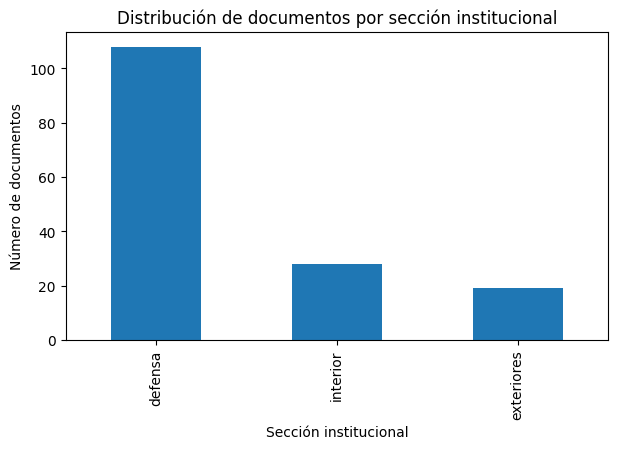

In [4]:
ax = class_distribution.plot(
    kind="bar",
    x=TARGET_COL,
    y="n_documents",
    legend=False,
    figsize=(7, 4),
    title="Distribución de documentos por sección institucional"
)

ax.set_xlabel("Sección institucional")
ax.set_ylabel("Número de documentos")

## 4. Definición de variables del problema

La formulación inicial del problema será:

- `X = text_clean_base`
- `y = moncloa_section`

Esta versión es la más limpia metodológicamente porque el modelo aprende a partir del contenido textual del documento y no de metadatos institucionales derivados de La Moncloa.

Como versión secundaria, se podría evaluar una entrada combinada `title + text_clean_base`, pero no será el punto de partida.

In [5]:
X = df_labeled[TEXT_COL].copy()
y = df_labeled[TARGET_COL].copy()

print(f"Número de documentos en X: {len(X)}")
print(f"Número de etiquetas en y: {len(y)}")
print(f"Clases: {sorted(y.unique())}")

X.head()

Número de documentos en X: 155
Número de etiquetas en y: 155
Clases: ['defensa', 'exteriores', 'interior']


0    C/SG/2820/20-02-82\nDTOR.\n\nNOTA INFORMATIVA\n\nASUNTO: Vista oral 2/81\n\n1.- DESARROLLO DE LA SESIÓN CORRESPONDIE...
1    C/SG/2896/22-02-82\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista oral 2/81. del Consejo Supremo de Justicia Militar.\n\n1.-...
2    C/SG/2992/24-02-82\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista Oral 2/81. del Consejo Supremo de Justicia Militar.\n\n## ...
3    C/SG/3.081/25-02-82\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista Oral 2/81 del Consejo Supremo de Justicia Militar.\n\n## ...
4    C/SG/3.249/26-02-82\nSG\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista oral de la causa 2/81, del Consejo Supremo de Justici...
Name: text_clean_base, dtype: object

## 5. Exclusión explícita de columnas con riesgo de leakage

Como la variable objetivo es `moncloa_section`, no se deben utilizar como variables predictoras columnas que revelen directa o indirectamente esa etiqueta.

Columnas excluidas por leakage:

- `moncloa_id`
- `moncloa_section`
- `moncloa_subsection`
- `final_match_status`
- `coverage_moncloa`

También se excluyen identificadores o enlaces como `doc_id`, `source_document_id`, `detail_url` y `pdf_url`, ya que no aportan contenido semántico generalizable.

In [6]:
leakage_columns = [
    "moncloa_id",
    "moncloa_section",
    "moncloa_subsection",
    "final_match_status",
    "coverage_moncloa",
]

identifier_columns = [
    "doc_id",
    "source_document_id",
    "detail_url",
    "pdf_url",
]

candidate_excluded_columns = leakage_columns + identifier_columns

available_excluded_columns = [col for col in candidate_excluded_columns if col in df_labeled.columns]

print("Columnas excluidas del conjunto de variables predictoras:")
for col in available_excluded_columns:
    print(f"- {col}")

Columnas excluidas del conjunto de variables predictoras:
- moncloa_id
- moncloa_section
- moncloa_subsection
- final_match_status
- coverage_moncloa
- doc_id
- source_document_id
- detail_url
- pdf_url


## 6. Planteamiento de validación train/test o validación cruzada

La validación deberá ser estratificada para conservar la proporción de clases en train y test.

Dado que el número de documentos no es muy grande, se valoran dos opciones:

1. `train_test_split` estratificado como primera aproximación.
2. Validación cruzada estratificada para obtener una estimación más estable.

En ambos casos, cualquier vectorizador textual deberá ajustarse únicamente con los datos de entrenamiento para evitar leakage.

In [7]:
min_class_size = y.value_counts().min()
n_classes = y.nunique()

print(f"Número de clases: {n_classes}")
print(f"Tamaño mínimo de clase: {min_class_size}")

if min_class_size >= 5:
    print("La validación cruzada estratificada con hasta 5 folds parece viable.")
elif min_class_size >= 3:
    print("La validación cruzada estratificada debería usar pocos folds.")
else:
    print("La muestra por clase es demasiado pequeña para una validación cruzada estable.")

Número de clases: 3
Tamaño mínimo de clase: 19
La validación cruzada estratificada con hasta 5 folds parece viable.


## 7. Pipeline futuro: TF-IDF + clasificador lineal

Para la entrega final se plantea un pipeline inicial sencillo e interpretable:

1. `TfidfVectorizer` sobre `text_clean_base`.
2. Clasificador lineal:
   - Regresión Logística.
   - Linear SVM.
3. Evaluación con:
   - accuracy;
   - macro F1;
   - matriz de confusión;
   - revisión de errores.

El pipeline completo se implementará más adelante. En esta fase solo se deja definido el enfoque metodológico.

In [8]:
# Pipeline previsto para la entrega final.
# No se entrena en esta versión inicial del notebook.

planned_pipeline = {
    "input": "text_clean_base",
    "target": "moncloa_section",
    "vectorizer": "TfidfVectorizer",
    "candidate_models": [
        "LogisticRegression",
        "LinearSVM",
    ],
    "validation": [
        "Stratified train/test split",
        "Stratified cross-validation",
    ],
    "metrics": [
        "accuracy",
        "macro_f1",
        "confusion_matrix",
    ],
}

planned_pipeline

{'input': 'text_clean_base',
 'target': 'moncloa_section',
 'vectorizer': 'TfidfVectorizer',
 'candidate_models': ['LogisticRegression', 'LinearSVM'],
 'validation': ['Stratified train/test split', 'Stratified cross-validation'],
 'metrics': ['accuracy', 'macro_f1', 'confusion_matrix']}

## 8. Conclusión de viabilidad

El mini caso es viable porque existe una variable objetivo definida, `moncloa_section`, para 155 documentos, y todos ellos cuentan con texto limpio disponible en `text_clean_base`. Esto permite plantear una tarea de clasificación supervisada de textos, complementando los mini casos exploratorios y no supervisados del proyecto.

La variable objetivo contiene tres clases institucionales: `defensa` con 108 documentos, `interior` con 28 y `exteriores` con 19. Aunque hay muestra suficiente para entrenar un modelo inicial, la distribución está claramente desbalanceada, ya que casi el 70 % de los documentos etiquetados pertenecen a `defensa`.

Por tanto, en la fase final no será adecuado evaluar el modelo únicamente con accuracy. Será necesario utilizar validación estratificada, métricas robustas frente al desbalance, como macro F1, y una matriz de confusión para comprobar si el modelo aprende también las clases minoritarias. Además, deberán excluirse del entrenamiento las columnas que puedan introducir leakage.

Los 12 documentos sin etiqueta institucional no se usarán para entrenar ni evaluar el modelo, aunque podrían clasificarse posteriormente como documentos no etiquetados.